# Analysis: Mechanistic Variability

We have trained several different Tiny RNN model architectures on a simple reversal task.
What we found is that GRU's trained on the task have varying underlying gating mechanisms.
We sought to minimise this variability by simplifying the architecture, while retaining the performance.


In [3]:
## setup ##
import os
os.chdir('/ceph/behrens/wsilver/reversal/code/')

from NM_TinyRNN.code.measures import analysis
from NM_TinyRNN.code.measures import mechanistic_variability as mech_var
from NM_TinyRNN.code.measures import plotting_stats
from NM_TinyRNN.code.measures import performance as perf

from NM_TinyRNN.code.models import submit_jobs # this is the code used to train models!

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload

CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# load data
#construct analysis_df and have a look at a subset of data!
info_df = submit_jobs.get_DA_info_df() #code used to submit jobs
all_models_df = analysis.get_analysis_df(info_df, mode='all') #code to aggregate all paths and some data
performance_df = perf.get_performance_df(all_models_df) #code to recompute evaluations and aggregate
best_model_df = perf.select_best_outer(performance_df) #

print("Available model types (model_type2):")
print(all_models_df.model_type2.unique())

Loaded analysis paths from cache: NM_TinyRNN/data/analysis/analysis_df.htsv
Loaded performance dataframe from cache: NM_TinyRNN/data/analysis/performance_df.htsv
Available model types (model_type2):
['vanilla+BC' 'vanilla+BC-DB' 'vanilla' 'GRU+BC' 'GRU+BC-DB' 'GRU'
 'lightGRU+BC' 'monoGRU+BC' 'monoGRU+BC-DB' 'monoGRU_abs'
 'monoGRU_no_hidden+BC-DB' 'monoGRU_hidden_only+BC-DB']


## Subject-level examples

To get an idea of what's going on at the level of hidden states across training seeds, let's look at some single-subject examples.

In [5]:
best_model_df.subject_id.unique()

array(['WS01', 'WS02', 'WS05', 'WS08', 'WS09', 'WS10', 'WS13', 'WS14',
       'WS16', 'WS18', 'WS20', 'WS22'], dtype=object)

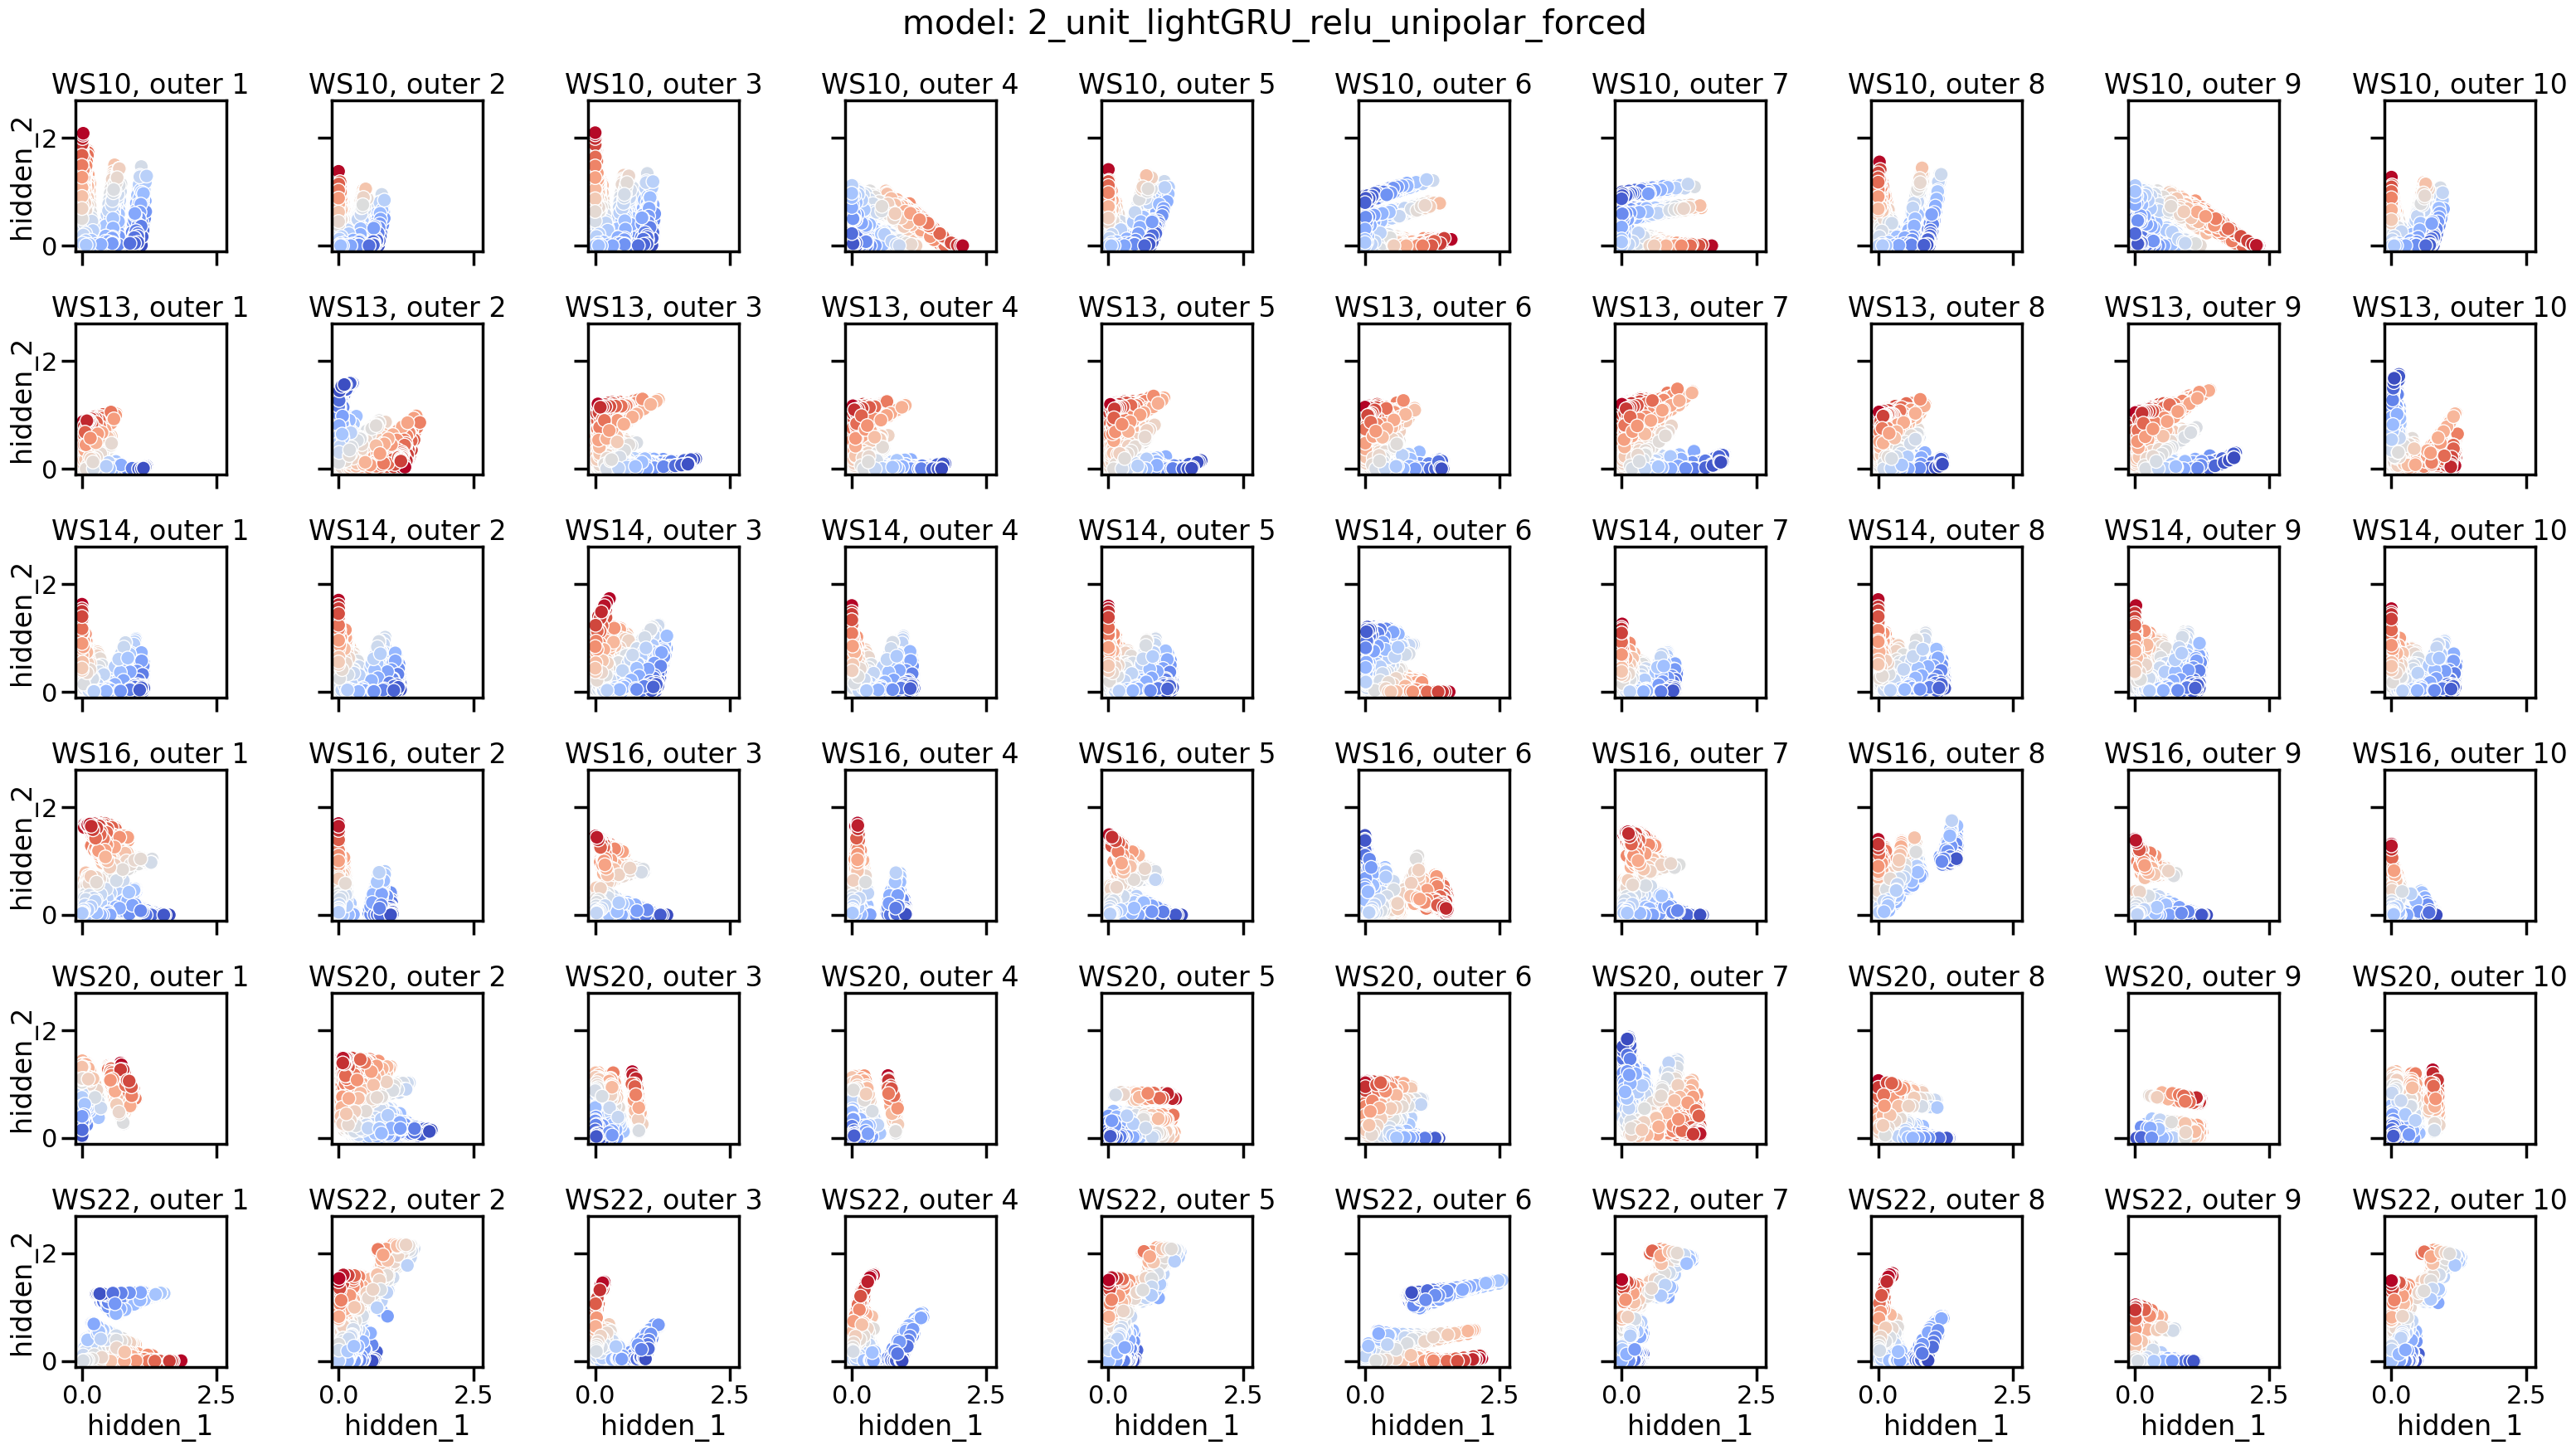

In [66]:
## Have a look at the mechanisms across folds !
subject_list = ['WS10', 'WS13', 'WS14', 'WS16', 'WS20', 'WS22']

subset_df = best_model_df.query('model_id=="2_unit_lightGRU_relu_unipolar_forced"')
subset_df = subset_df[subset_df.subject_id.isin(subject_list)]
subset_df = subset_df.sort_values(by=['subject_id','outer_loop_n'])

fig, ax = plt.subplots(len(subject_list),10,figsize=(32,len(subject_list)*3), sharex=True, sharey=True)
axes = ax.flatten()
for i,each_row in enumerate(subset_df.itertuples()):
    trials_data = analysis.load_data(each_row.trials_data_path)
    sns.scatterplot(trials_data, x= 'hidden_1',y='hidden_2',
                    hue = 'logit_value', palette='coolwarm',
                    legend = False, ax = axes[i])
    axes[i].set_title(f'{each_row.subject_id}, outer {each_row.outer_loop_n}')
    axes[i].axis('square')
fig.suptitle(f'model: {each_row.model_id}')
fig.tight_layout()

## Similarities in activations (within model architecture)

In [10]:
# Across all gating architectures - gating variability.
## Figure 2: variability in GRU model mechanisms.
model_list = ['GRU','GRU+BC','lightGRU+BC','monoGRU+BC','monoGRU+BC-DB','vanilla+BC-DB']
subject_list = ['WS10', 'WS13', 'WS14', 'WS16', 'WS20', 'WS22']
USE_BEST_MODELS = True

source_df = best_model_df if USE_BEST_MODELS else all_models_df
select_models = source_df.query('hidden_size==2 and input_encoding == "unipolar"').copy()
select_models = select_models[select_models.model_type2.isin(model_list)]
select_models = select_models[select_models.subject_id.isin(subject_list)]
select_models['model_id'] = select_models.model_type2
sim_df = mech_var.compute_similarities(select_models, similarity_measure='cosine')

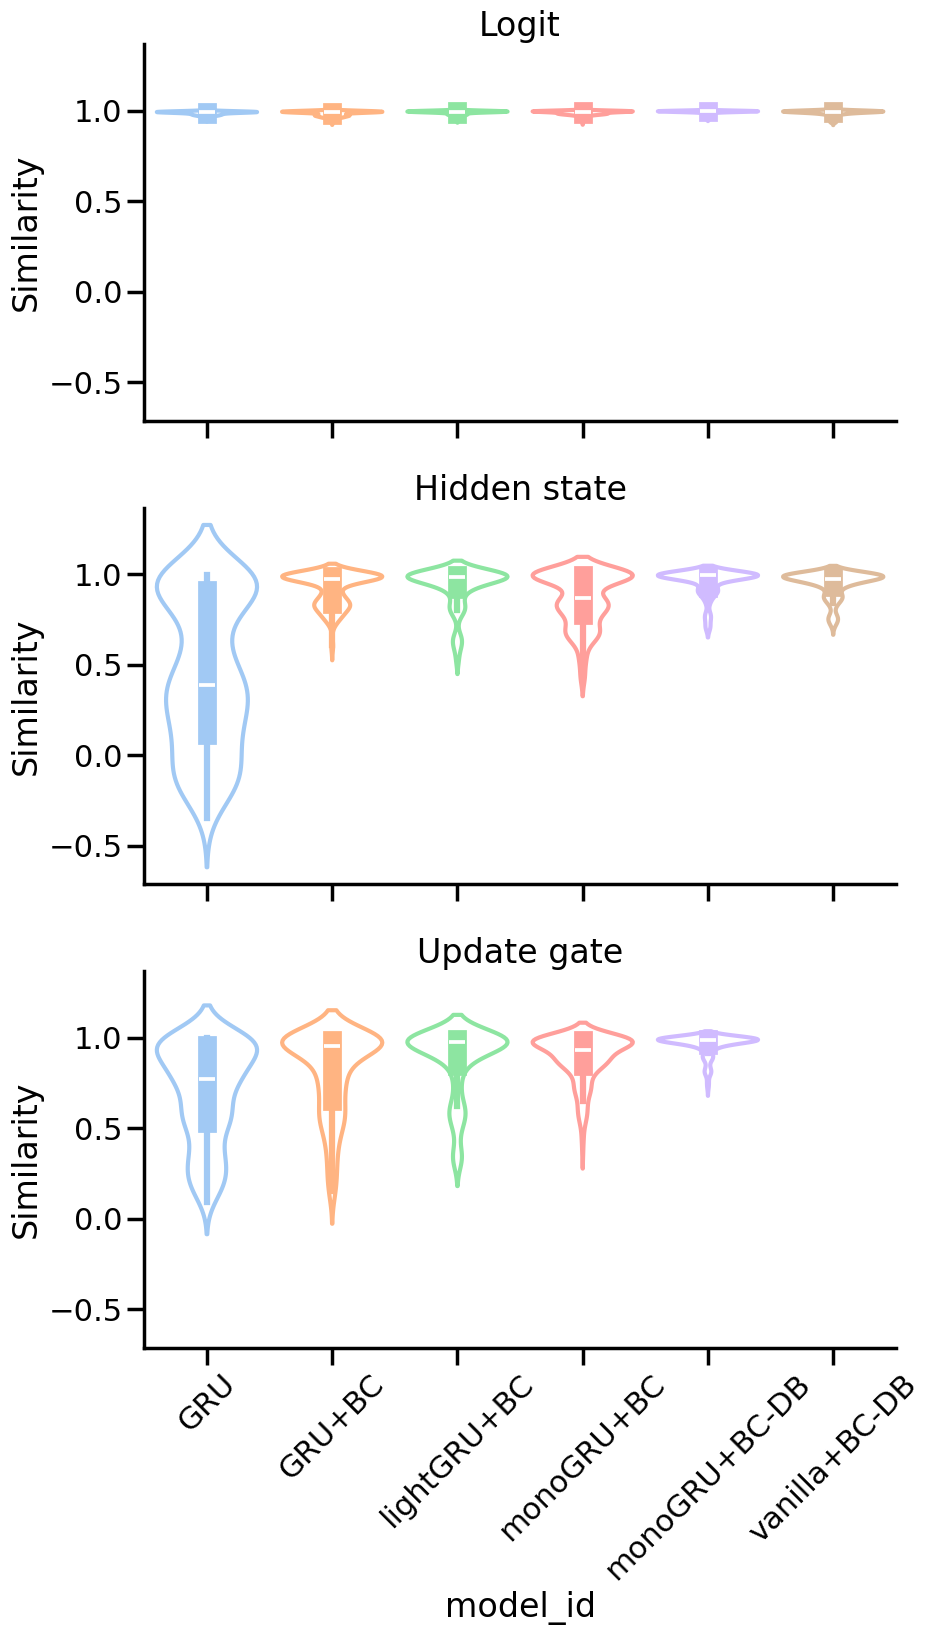

In [11]:
# 2D model similarity across gating architectures.
plot_df = sim_df.query('component!="reset_gate"')
sns.set_context('poster')
g = sns.catplot(plot_df, row='component',y='similarity', x='model_id',
               hue = 'model_id', palette = 'pastel',
               row_order = ['logit_value','hidden','gate_update'], 
               kind = 'violin', fill = False, aspect = 2)
titles = ["Logit", "Hidden state", "Update gate"]
g.set_axis_labels(y_var = 'Similarity')
for ax, title in zip(g.axes.flat, titles):
    ax.set_title(title)
    # Optional: rotate labels (45 degrees)
    ax.tick_params(axis='x', rotation=45)
    

## Similarities in weights (within model architecture)

In [52]:

## Figure 2: variability in GRU model mechanisms.
model_list = ['GRU','GRU+BC','lightGRU+BC','monoGRU+BC','monoGRU+BC-DB', 'vanilla+BC-DB']
select_models = best_model_df.query('hidden_size==2 and input_encoding == "unipolar" ')
select_models = select_models[select_models.model_type2.isin(model_list)]
select_models['model_id'] = select_models.model_type2

df = mech_var.compute_weight_similarities(select_models, 
                                          similarity_measure='cosine')

df

,model_id,subject_A,outer_loop_n_A,inner_loop_idx_A,subject_B,outer_loop_n_B,inner_loop_idx_B,within_subject,similarity,sim_original,similarity_measure
0,GRU,WS01,1,4,WS01,2,4,True,0.249872,0.249872,cosine
1,GRU,WS01,1,4,WS01,3,8,True,0.908640,0.908640,cosine
2,GRU,WS01,1,4,WS01,4,6,True,0.086651,0.086651,cosine
3,GRU,WS01,1,4,WS01,5,6,True,0.772104,0.772104,cosine
4,GRU,WS01,1,4,WS01,6,8,True,0.929486,0.929486,cosine
...,...,...,...,...,...,...,...,...,...,...,...
42716,vanilla+BC-DB,WS22,7,5,WS22,9,3,True,0.915351,0.915351,cosine
42717,vanilla+BC-DB,WS22,7,5,WS22,10,7,True,0.887235,0.887235,cosine
42718,vanilla+BC-DB,WS22,8,3,WS22,9,3,True,0.809729,0.809729,cosine
42719,vanilla+BC-DB,WS22,8,3,WS22,10,7,True,0.775969,0.775969,cosine


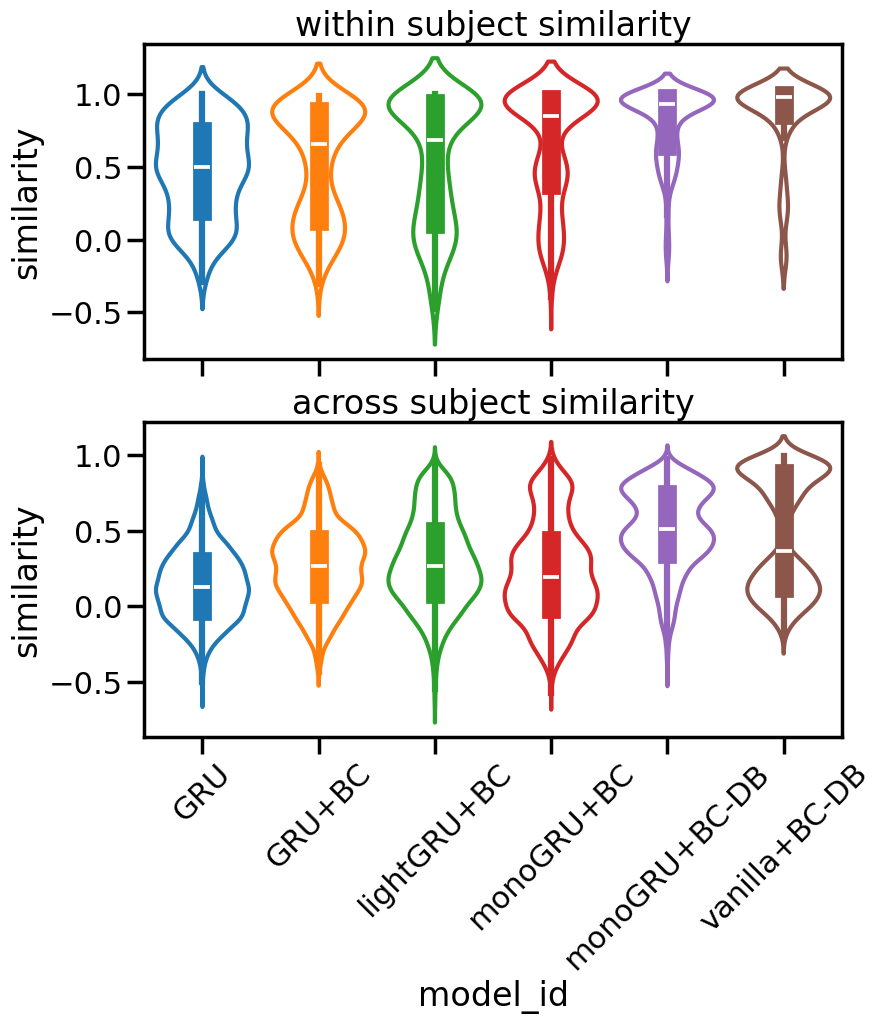

In [65]:
fig, ax = plt.subplots(2,1, figsize = (9,9), sharex=True)
sns.violinplot(df.query('within_subject == True'), 
               x= 'model_id', y = 'similarity', 
               hue= 'model_id', fill=False, ax = ax[0])
ax[0].set_title('within subject similarity')
sns.violinplot(df.query('within_subject == False'), 
               x= 'model_id', y = 'similarity', 
               hue= 'model_id', fill=False, ax = ax[1])
ax[1].set_title('across subject similarity')
ax[1].tick_params(axis='x', rotation=45)


In [45]:
sim_df

,model_id,subject_id,model_A_outer_n,model_A_inner_n,model_B_outer_n,model_B_inner_n,component,similarity,similarity_measure
0,GRU,WS10,1,1,1,3,hidden,NaN,cosine
1,GRU,WS10,1,1,1,4,hidden,NaN,cosine
2,GRU,WS10,1,1,1,6,hidden,NaN,cosine
3,GRU,WS10,1,1,1,7,hidden,NaN,cosine
4,GRU,WS10,1,1,2,1,hidden,NaN,cosine
...,...,...,...,...,...,...,...,...,...
125590,vanilla+BC-DB,WS22,10,3,10,6,logit_value,NaN,cosine
125591,vanilla+BC-DB,WS22,10,3,10,7,logit_value,NaN,cosine
125592,vanilla+BC-DB,WS22,10,5,10,6,logit_value,NaN,cosine
125593,vanilla+BC-DB,WS22,10,5,10,7,logit_value,NaN,cosine


In [14]:
example_models = best_model_df.query('model_id=="2_unit_monoGRU_relu_unipolar_forced_ndb" and subject_id=="WS18"')
for each_model in example_models.itertuples():
    trials_data= analysis.load_data(each_model.trials_data_path)
    model = analysis.load_data(each_model.model_pickle_path)
    break

trials_data
for name, p in model.named_parameters():
    print(name,p)

rnn.W_ih Parameter containing:
tensor([[-0.3913, -0.2319],
        [-1.1652,  0.7334],
        [ 1.0996,  0.9367]], requires_grad=True)
rnn.W_hh Parameter containing:
tensor([[ 0.3558, -0.1875],
        [-0.2154,  0.0904]], requires_grad=True)
rnn.W_iz Parameter containing:
tensor([[ 0.7260],
        [ 0.2169],
        [-1.1508]], requires_grad=True)
rnn.W_hz Parameter containing:
tensor([[-0.4848],
        [-1.3845]], requires_grad=True)
rnn.bias_h Parameter containing:
tensor([ 0.1719, -0.6601], requires_grad=True)
rnn.bias_z Parameter containing:
tensor(-0.1911, requires_grad=True)
rnn.hidden_0 Parameter containing:
tensor([ 0.5322, -0.0322], requires_grad=True)
rnn.z_0 Parameter containing:
tensor([0.0017], requires_grad=True)
decoder.weight Parameter containing:
tensor([[ 1.2201, -1.1064],
        [-1.2013,  1.1067]], requires_grad=True)


/tmp/ipykernel_1141582/3974622457.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['context->update gate','action->update gate', 'outcome->update gate','hidden->update gate'])


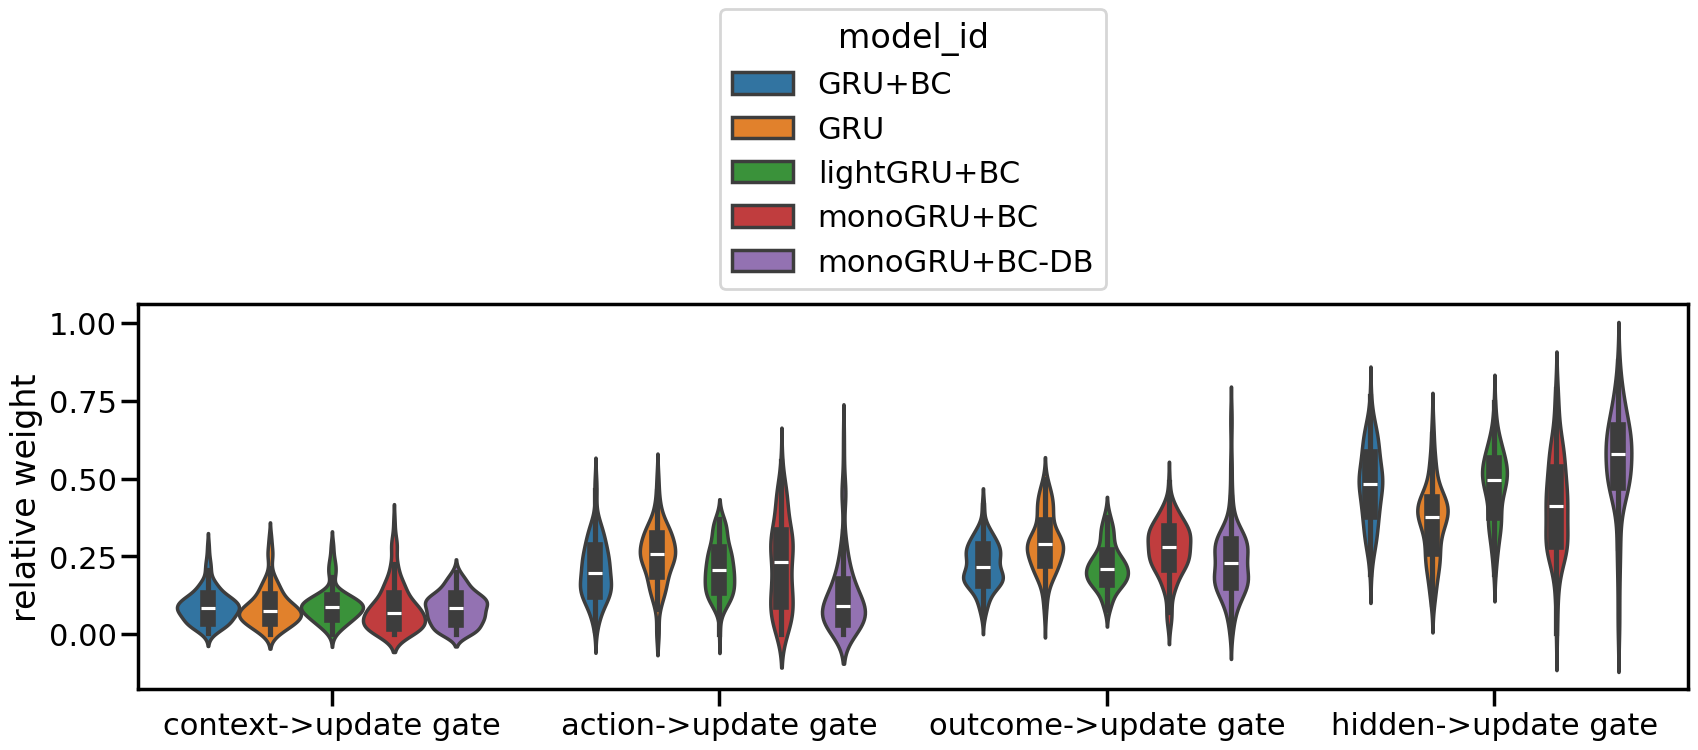

In [ ]:
reload(mech_var)
contributions_df = mech_var.parameter_contribution_df(select_models)
update_gate_df = contributions_df[contributions_df.variable.str.contains('update')]
update_gate_df = update_gate_df.dropna()

fig, ax = plt.subplots(figsize=(20, 5))
palette = sns.color_palette('pastel', n_colors=16)  # or 'husl', 'pastel', etc.

sns.violinplot(data=update_gate_df, 
               x='variable', y='value', 
               hue='model_id', 
              dodge=True, ax=ax, )
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, 1))
ax.set_xticklabels(['context->update gate', 'action->update gate', 'outcome->update gate','hidden->update gate'])
handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles, ['GRU', 'monoGRU*'], title='', loc='lower center', 
#         bbox_to_anchor=(0.5, 1))
ax.set(xlabel = '',ylabel='relative weight')
plt.show()


In [35]:
params_dict = {k:v.detach().numpy() for k,v in model.named_parameters()}
np.abs(params_dict['rnn.W_hh'])

array([[0.35579574, 0.18745962],
       [0.21537717, 0.09037313]], dtype=float32)